# Movie Recommendation System 

## Import libraries and load dataset

In [1]:
import pandas as pd

In [2]:
movie_df = pd.read_csv('Movie_Id_Titles.csv')
u_df = pd.read_csv('u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])

In [3]:
movie_df.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
u_df.head()

,user_id,movie_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


In [5]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  1682 non-null   int64 
 1   title     1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB


In [6]:
u_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100003 entries, 0 to 100002
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100003 non-null  int64
 1   movie_id   100003 non-null  int64
 2   rating     100003 non-null  int64
 3   timestamp  100003 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


## Data Pre-processing

In [7]:
# List of unique values in 'u.(ratings)' dataset under column 'user_id'

# total users = 944

unique_movie = u_df.user_id.unique()
sorted(unique_movie)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [8]:
# List of unique values in 'u(ratings)' dataset under column 'movie_id'

unique_movie = u_df.movie_id.unique()
sorted(unique_movie)

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

In [9]:
# total count in col 'user_id' in u.dataset

u_df['user_id'].nunique()

944

In [10]:
# total count in col 'movie_id' in u.dataset

u_df['movie_id'].nunique()

1682

In [11]:
# check for null values in u.data(ratings)

u_df.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [12]:
# check for null values in movie_id dataset

movie_df.isnull().sum()

movie_id    0
title       0
dtype: int64

In [13]:
# we will create new dataset, each column would represent = 'user_id' and each row represents = 'movie_id'

new_dataset = u_df.pivot(index='movie_id',columns='user_id',values='rating')
new_dataset.head()

user_id,0,1,2,3,4,5,6,7,8,9,...,934,935,936,937,938,939,940,941,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,5.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,NaN,...,2.0,3.0,4.0,NaN,4.0,NaN,NaN,5.0,NaN,NaN
2,NaN,3.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
3,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,3.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
5,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# replace and fill NaN with 0

new_dataset.fillna(0,inplace=True)
new_dataset.head()

user_id,0,1,2,3,4,5,6,7,8,9,...,934,935,936,937,938,939,940,941,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,...,2.0,3.0,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0
2,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
5,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis

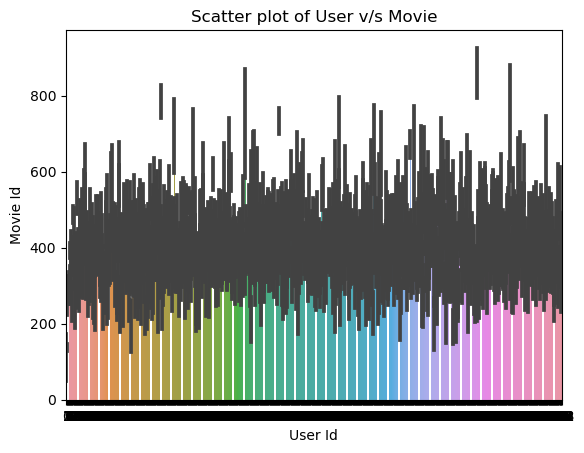

In [15]:
# plot shows User Id and Movie Id

import seaborn as sns
ax = sns.barplot(x='user_id', y='movie_id', data=u_df)
ax.set(xlabel='User Id', ylabel='Movie Id', title='Scatter plot of User v/s Movie');

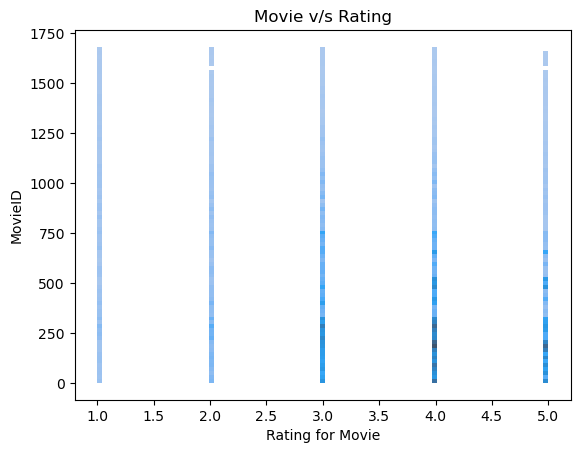

In [16]:
# plot shows Movies and rating received for the movie

ax = sns.histplot(x='rating', y='movie_id', data=u_df)
ax.set(xlabel='Rating for Movie', ylabel='MovieID', title='Movie v/s Rating');

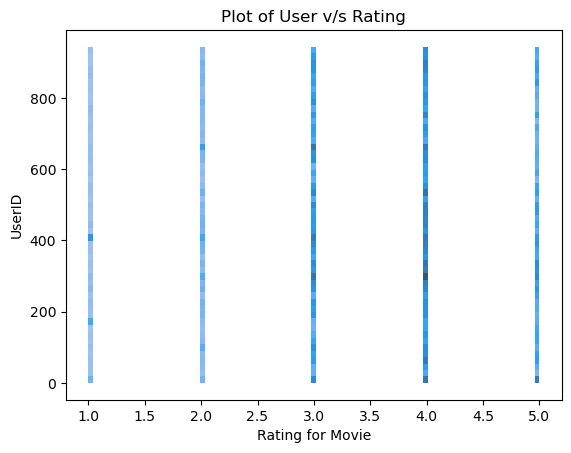

In [17]:
# plot shows UserId and ratings given by the Users

ax = sns.histplot(x='rating', y='user_id', data=u_df)
ax.set(xlabel='Rating for Movie', ylabel='UserID', title='Plot of User v/s Rating');

## Filter the movie list

In [18]:
# We will fit a filter for the Users and Movies to get optimum output 

# Highly engaging Users and High rated movies will have more relevance in the recommendation

# Minimum 10 user votes will qualify a Movie. Minimum 50 movies voted by a user will be selected in the list

zero_user_voted = u_df.groupby('movie_id')['rating'].agg('count')
zero_movies_voted = u_df.groupby('user_id')['rating'].agg('count')


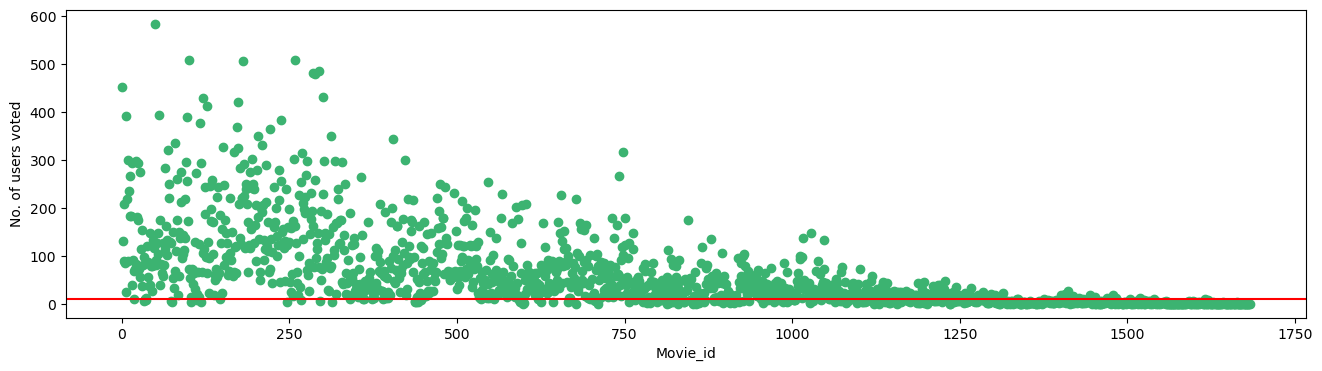

In [19]:
# plot shows movies which received atleast 10 votes from different users

import matplotlib.pyplot as plt
%matplotlib inline

f,ax = plt.subplots(1,1,figsize=(16,4))
# ratings['rating'].plot(kind='hist')
plt.scatter(zero_user_voted.index,zero_user_voted,color='mediumseagreen')
plt.axhline(y=10,color='r')
plt.xlabel('Movie_id')
plt.ylabel('No. of users voted')
plt.show()

In [20]:
# set the threshold for movies : received atleast 10 votes from different users

new_dataset = new_dataset.loc[zero_user_voted[zero_user_voted > 10].index,:]

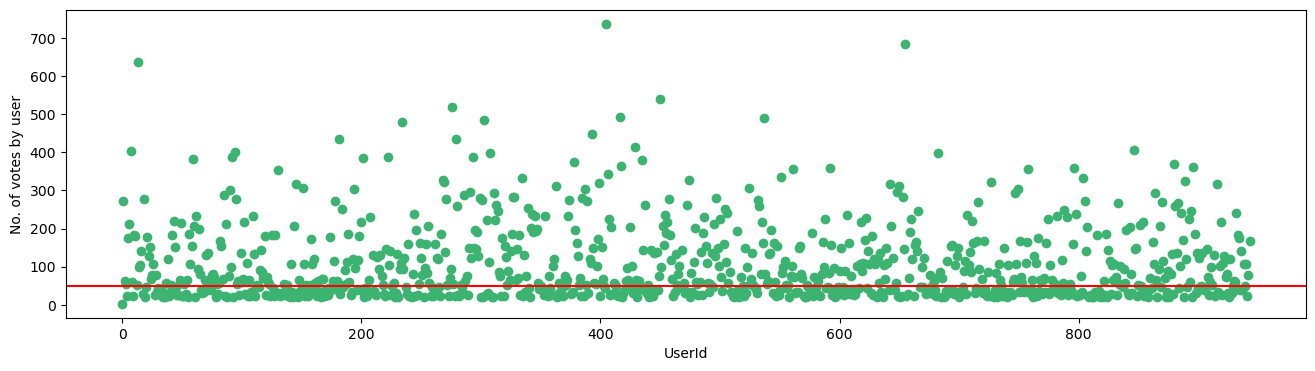

In [21]:
# plt shows user_id voted atleast 50 random movies

f,ax = plt.subplots(1,1,figsize=(16,4))
plt.scatter(zero_movies_voted.index,zero_movies_voted,color='mediumseagreen')
plt.axhline(y=50,color='r')
plt.xlabel('UserId')
plt.ylabel('No. of votes by user')
plt.show()

In [22]:
# set the threshold for user_id : voted atleast 50 random movies

new_dataset=new_dataset.loc[:,zero_movies_voted[zero_movies_voted > 50].index]
new_dataset

user_id,1,2,3,5,6,7,8,10,11,12,...,930,931,932,933,934,936,938,940,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,4.0,0.0,4.0,4.0,0.0,0.0,4.0,0.0,0.0,...,3.0,0.0,4.0,3.0,2.0,4.0,4.0,0.0,0.0,0.0
2,3.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,5.0,...,0.0,0.0,0.0,3.0,5.0,0.0,0.0,2.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## CSR Matrix for Data Sparsity

In [23]:
# as we have enabled the filter on the dataset to get most relevant input, the dataset has shrunk in size

# lets remove sparsity using 'csr_matrix' method to fill the sparse data 

from scipy.sparse import csr_matrix
csr_dataset = csr_matrix(new_dataset.values)
new_dataset.reset_index(inplace=True)

## KNN algorithm and build recommendation system

In [24]:
# import KNN algorithm to compute similarity with 'cosine distance'

from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(metric='cosine',algorithm='brute',n_neighbors=20,n_jobs=1)
knn.fit(csr_dataset)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=1, n_neighbors=20)

In [25]:
# recommendation function to predict similar movies

def get_movie_recommendation(movie_name):
    n_movies_to_reccomend = 10
    movie_list = movie_df[movie_df['title'].str.contains(movie_name)]  
    if len(movie_list):        
        movie_idx= movie_list.iloc[0]['movie_id']
        movie_idx = new_dataset[new_dataset['movie_id'] == movie_idx].index[0]
        distances , indices = knn.kneighbors(csr_dataset[movie_idx],n_neighbors=n_movies_to_reccomend+1)    
        rec_movie_indices = sorted(list(zip(indices.squeeze().tolist(),distances.squeeze().tolist())),key=lambda x: x[1])[:0:-1]
        recommend_frame = []
        for val in rec_movie_indices:
            movie_idx = new_dataset.iloc[val[0]]['movie_id']
            idx = movie_df[movie_df['movie_id'] == movie_idx].index
            recommend_frame.append({'Title':movie_df.iloc[idx]['title'].values[0],'Distance':val[1]})
        df = pd.DataFrame(recommend_frame,index=range(1,n_movies_to_reccomend+1))
        return df
    else:
        return "Movie title doesn't exist. Please recheck title"

In [26]:
# let use the 'movie recommendation system

get_movie_recommendation('GoldenEye')

,Title,Distance
1,Die Hard: With a Vengeance (1995),0.405387
2,Batman Returns (1992),0.405038
3,Terminator 2: Judgment Day (1991),0.398804
4,Die Hard 2 (1990),0.398710
5,Cliffhanger (1993),0.393291
6,Stargate (1994),0.386704
7,Batman (1989),0.377559
8,Top Gun (1986),0.375507
9,True Lies (1994),0.371815
10,Under Siege (1992),0.330998
